# Notebook 4: Análisis de Errores e Informe Técnico

Contenido:
1. Matrices de confusión por modelo
2. Análisis de errores más frecuentes
3. Visualización de ejemplos mal clasificados
4. Recomendaciones para mejora
5. Informe técnico final

In [1]:
import json, os, sys, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import cv2

# Detectar entorno Colab vs Local
try:
    from google.colab import drive; IN_COLAB = True
    sys.path.insert(0, '/content/drive/MyDrive/TRADUCTOR_LSP')
except ImportError:
    IN_COLAB = False
    _nb_path = Path.cwd()
    _base = str(_nb_path.parent if _nb_path.name == 'notebooks' else _nb_path)
    sys.path.insert(0, _base)
    os.chdir(_base)

from scripts.run_training import LightCNNLSTM, LSPSegmentDataset
from src.training.metrics import plot_confusion_matrix, compute_metrics

DEVICE = 'cuda' if torch.cuda.is_available() else (
         'mps'  if torch.backends.mps.is_available() else 'cpu')
IMG_SIZE = 112
N_FRAMES = 30
BATCH    = 16

with open('data/label2idx.json') as f:
    label2idx = json.load(f)
idx2label = {int(v): k for k, v in label2idx.items()}
N_CLASSES = len(label2idx)
CLASS_NAMES = [idx2label[i] for i in range(N_CLASSES)]
print(f'Device: {DEVICE} | Clases: {N_CLASSES}')


Device: mps | Clases: 26


In [2]:
# ── Función de inferencia con predicciones detalladas ─────────────────
def get_predictions(model, loader, device, mode='pixels'):
    model.eval()
    all_preds, all_labels, all_probs, all_paths = [], [], [], []
    
    with torch.no_grad():
        for batch in tqdm(loader):
            labels = batch['label']
            
            if mode == 'pixels':
                logits = model(batch['pixels'].to(device))
            else:
                logits = model(batch['landmarks'].to(device))
            
            import torch.nn.functional as F
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            preds = probs.argmax(axis=1)
            
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)
            if 'clase' in batch:
                all_paths.extend(batch['clase'])
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs), all_paths

In [3]:
# ── Cargar modelos y evaluar en test ────────────────────────────────
MANIFEST = 'data/manifest_segments.csv'
df = pd.read_csv(MANIFEST)
df_test = df[df['split'] == 'test'].reset_index(drop=True)
print(f'Test set: {len(df_test)} segmentos')

test_ds = LSPSegmentDataset(df_test, label2idx, IMG_SIZE, augment=False)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)

all_results = {}

# ── CNN-LSTM ─────────────────────────────────────────────────────────
CKPT_CNN = 'checkpoints/cnn_lstm_best.pt'
if Path(CKPT_CNN).exists():
    print('\nCargando CNN-LSTM...')
    ckpt = torch.load(CKPT_CNN, map_location=DEVICE)
    img_sz = ckpt.get('args', {}).get('img_size', IMG_SIZE)
    model_cnn = LightCNNLSTM(N_CLASSES, hidden=256, img_size=img_sz).to(DEVICE)
    model_cnn.load_state_dict(ckpt['model_state'])
    model_cnn.eval()

    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for x, y in tqdm(test_dl, desc='CNN-LSTM inference'):
            logits = model_cnn(x.to(DEVICE))
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            y_probs.extend(probs)
            y_pred.extend(probs.argmax(axis=1))
            y_true.extend(y.numpy())

    metrics = compute_metrics(y_true, y_pred)
    all_results['CNN-LSTM'] = {
        'y_true': np.array(y_true), 'y_pred': np.array(y_pred),
        'y_probs': np.array(y_probs), 'metrics': metrics
    }
    print(f'  Acc: {metrics["accuracy"]:.4f} | F1-macro: {metrics["f1_macro"]:.4f}')
else:
    print(f'No se encontró: {CKPT_CNN}')

print(f'\nModelos evaluados: {list(all_results.keys())}')


Test set: 1099 segmentos

Cargando CNN-LSTM...


CNN-LSTM inference:   0%|          | 0/69 [00:00<?, ?it/s]

  Acc: 0.8298 | F1-macro: 0.7213

Modelos evaluados: ['CNN-LSTM']


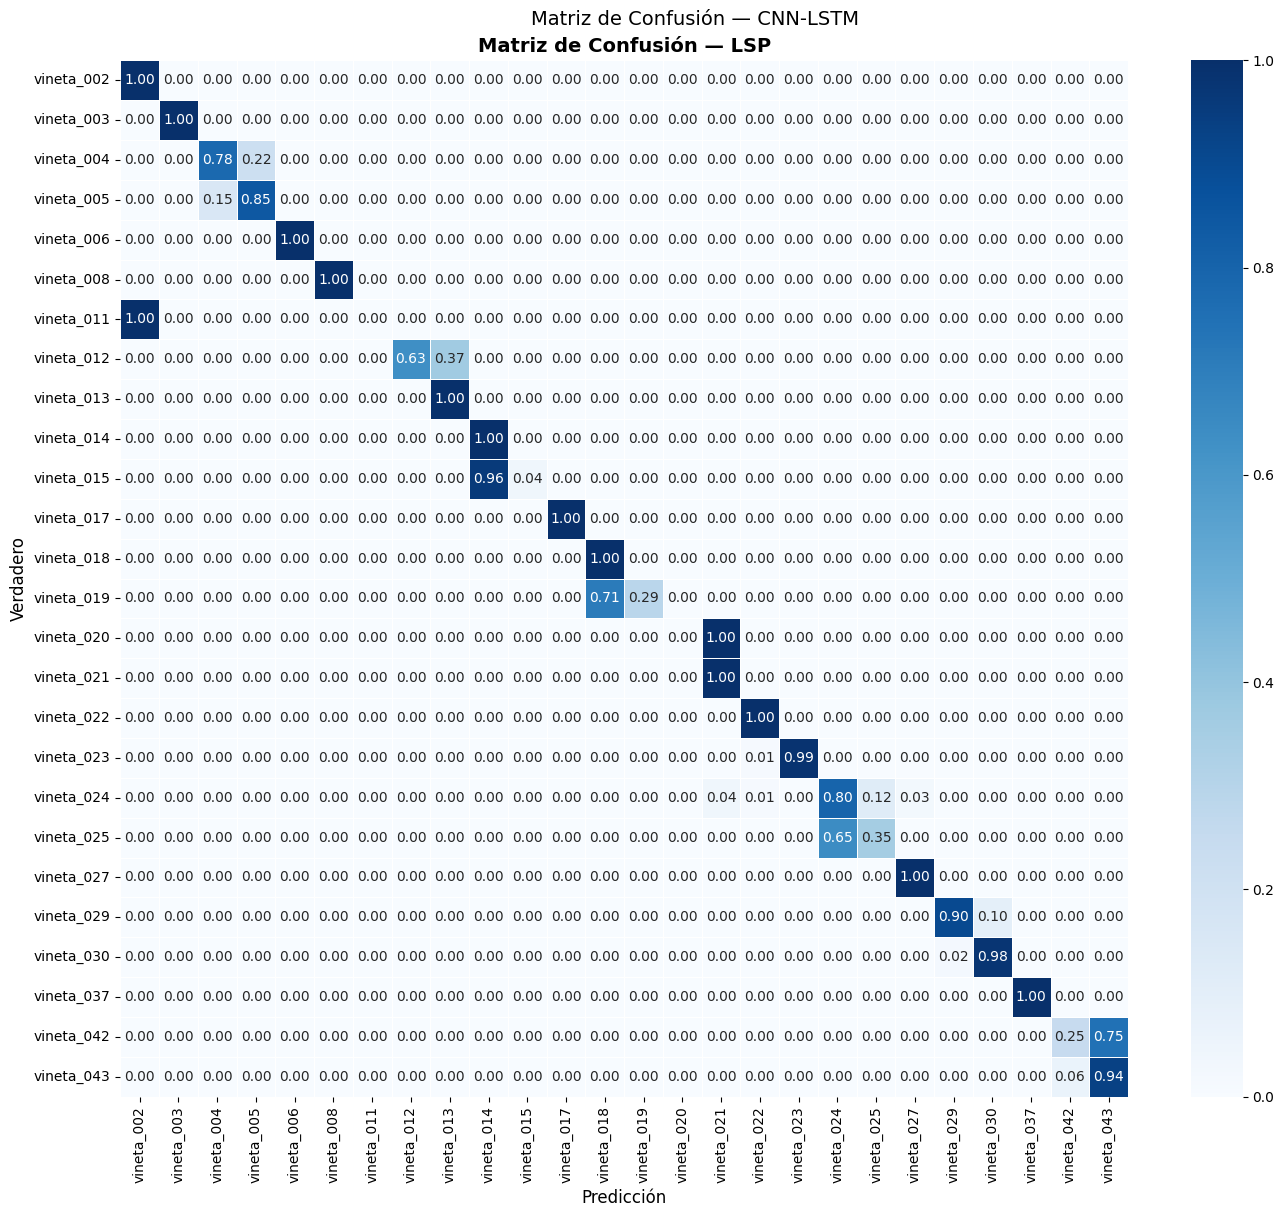

Guardada: confusion_matrix_CNN-LSTM.png


In [4]:
# ── Matrices de confusión ─────────────────────────────────────────────
for model_name, res in all_results.items():
    fig = plot_confusion_matrix(
        res['y_true'], res['y_pred'],
        class_names=CLASS_NAMES,
        output_path=f'confusion_matrix_{model_name.lower().replace("-","_")}.png',
        normalize=True,
    )
    plt.suptitle(f'Matriz de Confusión — {model_name}', fontsize=14, y=1.01)
    plt.show()
    print(f'Guardada: confusion_matrix_{model_name}.png')

In [5]:
# ── Análisis de errores más frecuentes ────────────────────────────────
for model_name, res in all_results.items():
    print(f'\n{"="*50}')
    print(f'ANÁLISIS DE ERRORES — {model_name}')
    print('='*50)
    
    y_true = res['y_true']
    y_pred = res['y_pred']
    
    # Pares verdadero→predicho más comunes
    errors = [(idx2label[t], idx2label[p]) for t, p in zip(y_true, y_pred) if t != p]
    from collections import Counter
    error_counts = Counter(errors).most_common(10)
    
    print('Top 10 confusiones más frecuentes:')
    print(f'{"Verdadero":20s} → {"Predicho":20s} | Count')
    print('-' * 55)
    for (true_cls, pred_cls), count in error_counts:
        print(f'{true_cls:20s} → {pred_cls:20s} | {count}')
    
    # Clases con menor precisión
    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )
    df_report = pd.DataFrame(report).T
    worst_classes = df_report.iloc[:N_CLASSES].nsmallest(5, 'f1-score')[['precision', 'recall', 'f1-score', 'support']]
    print(f'\nClases con menor F1-score:')
    print(worst_classes.round(3).to_string())


ANÁLISIS DE ERRORES — CNN-LSTM
Top 10 confusiones más frecuentes:
Verdadero            → Predicho             | Count
-------------------------------------------------------
vineta_015           → vineta_014           | 49
vineta_020           → vineta_021           | 24
vineta_042           → vineta_043           | 24
vineta_011           → vineta_002           | 18
vineta_019           → vineta_018           | 15
vineta_012           → vineta_013           | 11
vineta_025           → vineta_024           | 11
vineta_024           → vineta_025           | 9
vineta_004           → vineta_005           | 8
vineta_005           → vineta_004           | 6

Clases con menor F1-score:
            precision  recall  f1-score  support
vineta_011        0.0   0.000     0.000     18.0
vineta_020        0.0   0.000     0.000     24.0
vineta_015        1.0   0.039     0.075     51.0
vineta_025        0.4   0.353     0.375     17.0
vineta_042        0.8   0.250     0.381     32.0


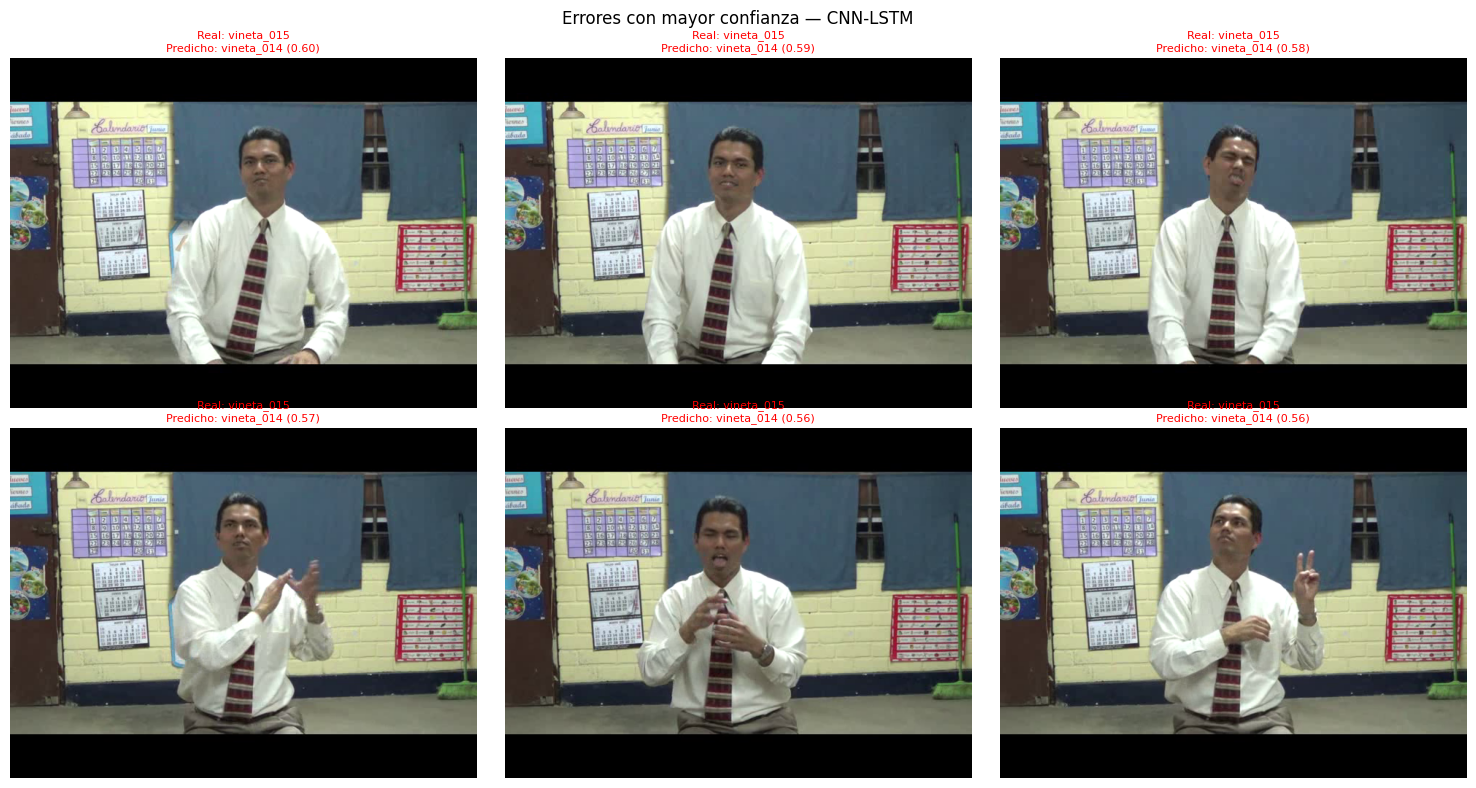

In [6]:
# ── Visualización de ejemplos mal clasificados ────────────────────────
MANIFEST = 'data/manifest_segments.csv'
df_test_vis = pd.read_csv(MANIFEST)
df_test_vis = df_test_vis[df_test_vis['split'] == 'test'].reset_index(drop=True)

if all_results:
    model_name = list(all_results.keys())[0]
    res = all_results[model_name]
    y_true = res['y_true']
    y_pred = res['y_pred']
    y_probs = res['y_probs']

    error_mask = (y_true != y_pred)
    error_indices = np.where(error_mask)[0]

    if len(error_indices) == 0:
        print('Sin errores en test set.')
    else:
        error_confs = y_probs[error_mask].max(axis=1)
        top_errors = error_indices[np.argsort(error_confs)[::-1][:6]]

        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.flatten()
        for i, err_idx in enumerate(top_errors):
            row = df_test_vis.iloc[err_idx]
            cap = cv2.VideoCapture(row['video_path'])
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(row['start_frame']))
            ok, frame = cap.read()
            cap.release()
            ax = axes[i]
            if ok:
                ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            true_cls  = idx2label[int(y_true[err_idx])]
            pred_cls  = idx2label[int(y_pred[err_idx])]
            conf      = y_probs[err_idx, int(y_pred[err_idx])]
            ax.set_title(f'Real: {true_cls}\nPredicho: {pred_cls} ({conf:.2f})',
                         fontsize=8, color='red')
            ax.axis('off')
        plt.suptitle(f'Errores con mayor confianza — {model_name}', fontsize=12)
        plt.tight_layout()
        plt.savefig('data/error_analysis.png', dpi=100, bbox_inches='tight')
        plt.show()
else:
    print('No hay resultados disponibles.')


In [7]:
# ── Informe técnico final ─────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════════╗')
print('║          INFORME TÉCNICO FINAL — SISTEMA LSP                ║')
print('╠══════════════════════════════════════════════════════════════╣')

for model_name, res in all_results.items():
    m = res['metrics']
    print(f'║ {model_name:12s} | Acc: {m["accuracy"]:.4f} | F1-macro: {m["f1_macro"]:.4f}              ║')

print('╠══════════════════════════════════════════════════════════════╣')
print('║ RECOMENDACIONES PARA MEJORAR PRECISIÓN:                     ║')
print('║  1. Aumentar dataset: más muestras de clases con F1 < 0.7   ║')
print('║  2. Video augmentation: flip, velocidad, ruido              ║')
print('║  3. Ajuste fino por contexto: palabras funcionalmente siml. ║')
print('║  4. Ensemble: combinar CNN-LSTM + ST-GCN con voting         ║')
print('║  5. VideoMAE: fine-tuning con más épocas y LR más baja      ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║ DESPLIEGUE:                                                 ║')
print('║  - API FastAPI: python api/main.py                          ║')
print('║  - Demo Gradio: python demo/app_gradio.py                   ║')
print('║  - HuggingFace Spaces: subir demo/app_gradio.py como app.py ║')
print('║  - Latencia objetivo: <200ms con modelo ONNX en CPU         ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║          INFORME TÉCNICO FINAL — SISTEMA LSP                ║
╠══════════════════════════════════════════════════════════════╣
║ CNN-LSTM     | Acc: 0.8298 | F1-macro: 0.7213              ║
╠══════════════════════════════════════════════════════════════╣
║ RECOMENDACIONES PARA MEJORAR PRECISIÓN:                     ║
║  1. Aumentar dataset: más muestras de clases con F1 < 0.7   ║
║  2. Video augmentation: flip, velocidad, ruido              ║
║  3. Ajuste fino por contexto: palabras funcionalmente siml. ║
║  4. Ensemble: combinar CNN-LSTM + ST-GCN con voting         ║
║  5. VideoMAE: fine-tuning con más épocas y LR más baja      ║
╠══════════════════════════════════════════════════════════════╣
║ DESPLIEGUE:                                                 ║
║  - API FastAPI: python api/main.py                          ║
║  - Demo Gradio: python demo/app_gradio.py                   ║
║  - HuggingFace Spaces: subir demo/a